# **GROUP 3**

# **SOLAR POWER GENERATION**

### **EDA**

In [1]:
import numpy as np
print(np.__version__)

1.26.4


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import f_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df=pd.read_csv('solarpowergeneration.csv')

In [4]:
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [5]:
df.tail()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
2915,0.166453,63,27,13.9,4,10.0,75,10.0,29.93,6995
2916,0.064020,63,27,13.9,1,10.0,66,15.0,29.91,29490
2917,0.294494,63,27,13.9,2,10.0,68,21.0,29.88,17257
2918,0.524968,63,27,13.9,2,10.0,81,17.0,29.87,677
2919,0.755442,63,27,13.9,1,10.0,81,11.0,29.90,0


In [6]:
df['power-generated'].value_counts()

power-generated
0        1320
3           3
229         3
738         3
114         2
         ... 
12545       1
52          1
8277        1
22482       1
17257       1
Name: count, Length: 1529, dtype: int64

In [7]:
df.shape

(2920, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [9]:
# All columns are numeric columns

In [10]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [11]:
# datatypes
df.dtypes

distance-to-solar-noon         float64
temperature                      int64
wind-direction                   int64
wind-speed                     float64
sky-cover                        int64
visibility                     float64
humidity                         int64
average-wind-speed-(period)    float64
average-pressure-(period)      float64
power-generated                  int64
dtype: object

In [12]:
## missing values
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [13]:
df['average-wind-speed-(period)'].unique()

array([ 8.,  5.,  0.,  3., 23., 15.,  6.,  9., 18., 11., 10., 20., 14.,
       17.,  7., 22., 16., 25., 13., 21., 24., 26., 29., nan, 30., 28.,
       33., 31., 32., 38., 40., 39., 36.])

In [14]:
df.isnull().sum().sum()/len(df)*100

0.03424657534246575

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [17]:
## Duplicates

In [18]:
df.duplicated().sum()

0

In [19]:
## There are no duplicate values

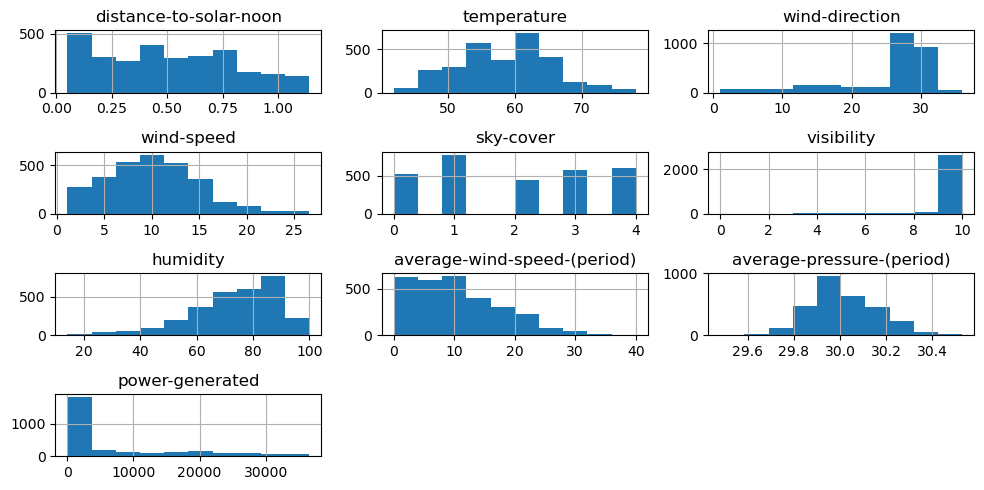

In [20]:
df.hist()
plt.tight_layout()
plt.show()
# Skewness: Less than -1 or greater than +1 high skewness, Humidity
# -0.5 to +0.5 : Moderate skewness, temperature

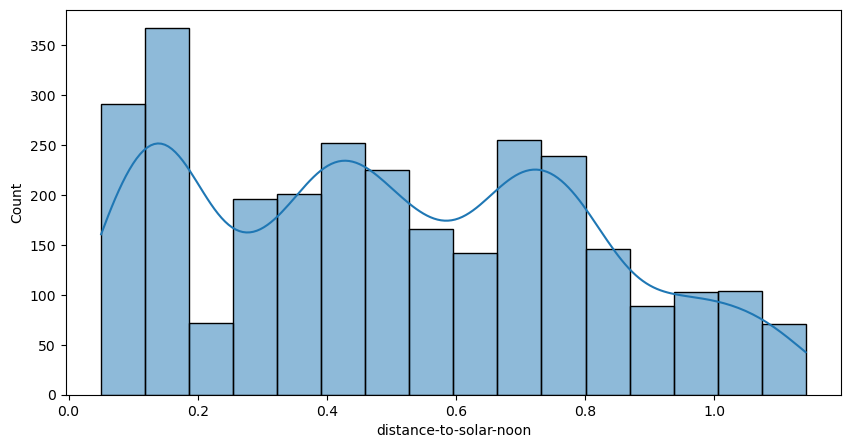

In [21]:
sns.histplot(data=df,x='distance-to-solar-noon',kde=True)
plt.show()

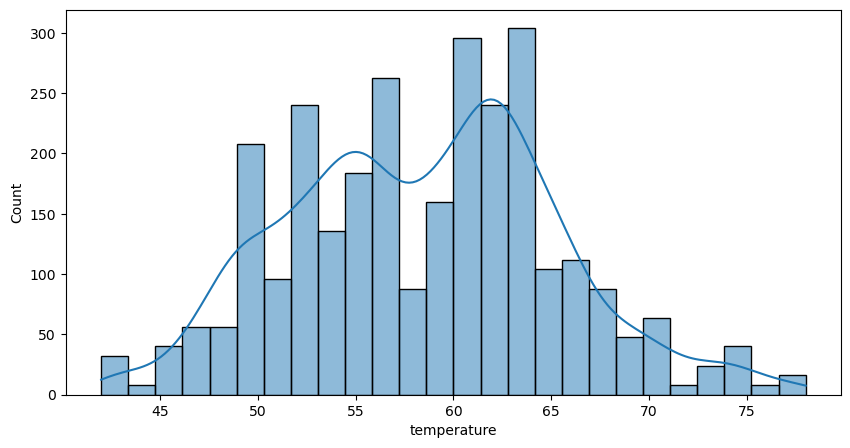

In [22]:
sns.histplot(data=df,x='temperature',kde=True)
plt.show()

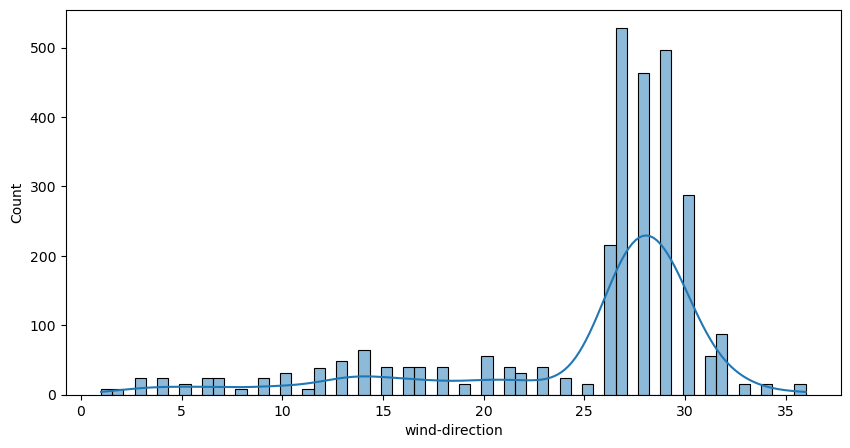

In [23]:
sns.histplot(data=df,x='wind-direction',kde=True)
plt.show()

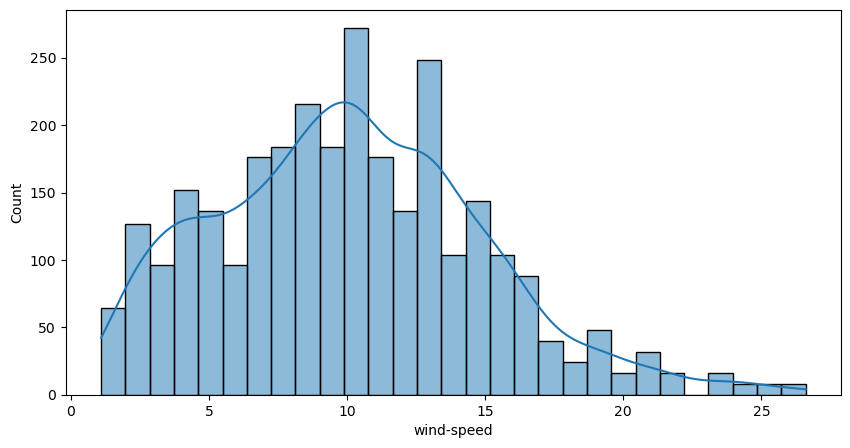

In [24]:
sns.histplot(data=df,x='wind-speed',kde=True)
plt.show()

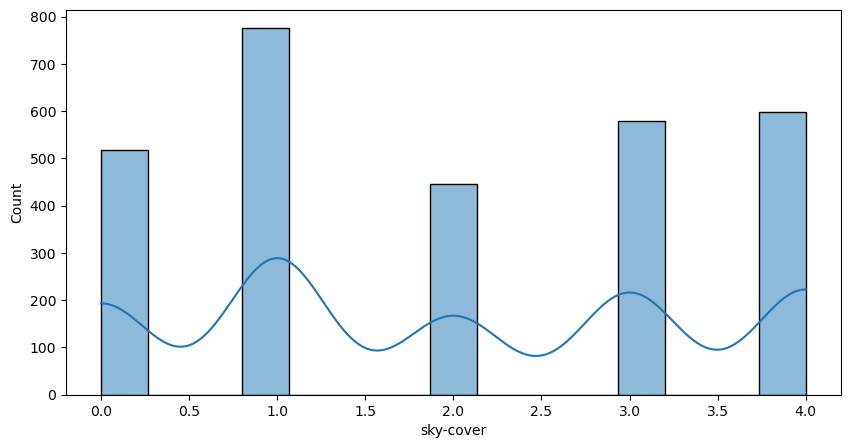

In [25]:
sns.histplot(data=df,x='sky-cover',kde=True)
plt.show()

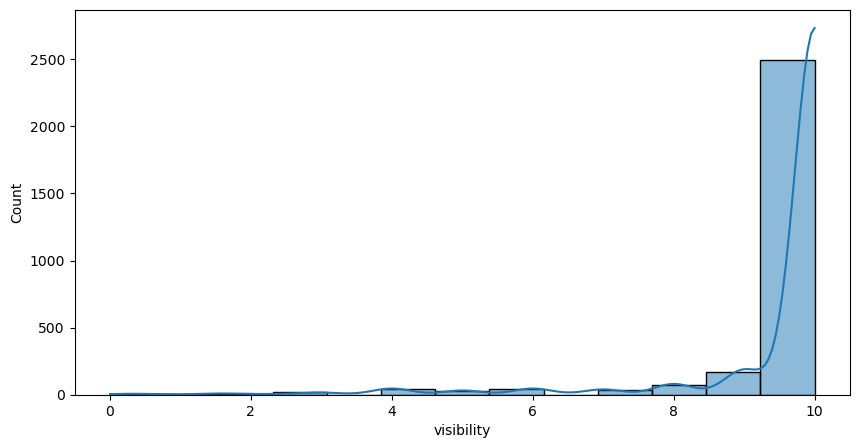

In [26]:
sns.histplot(data=df,x='visibility',kde=True)
plt.show()

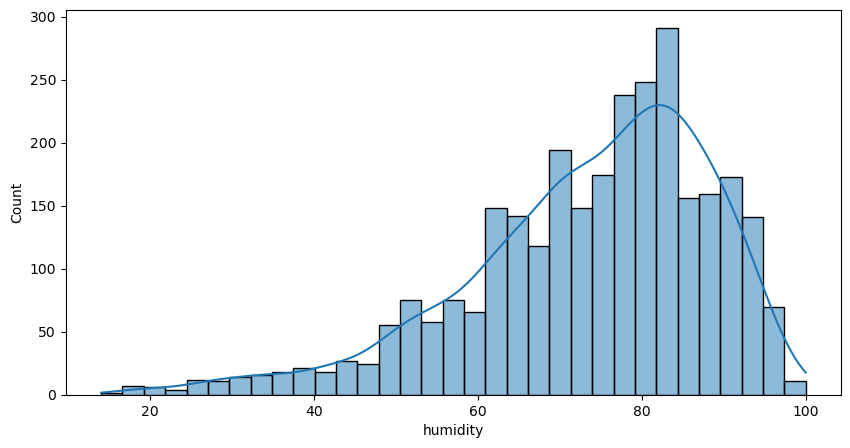

In [27]:
sns.histplot(data=df,x='humidity',kde=True)
plt.show()

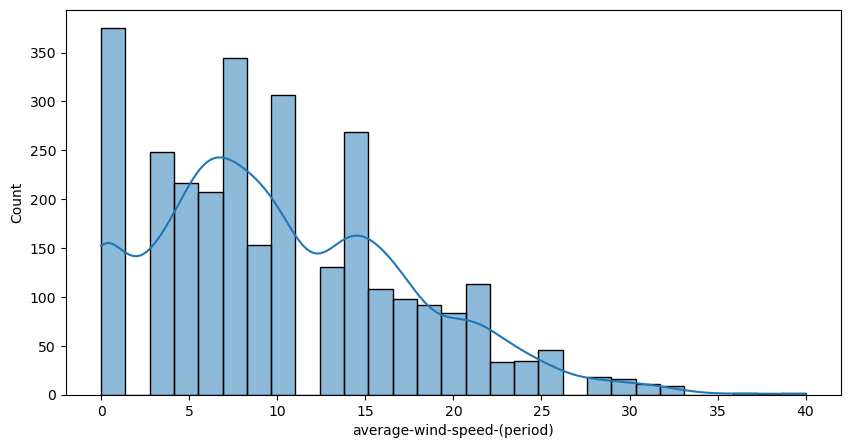

In [28]:
sns.histplot(data=df,x='average-wind-speed-(period)',kde=True)
plt.show()

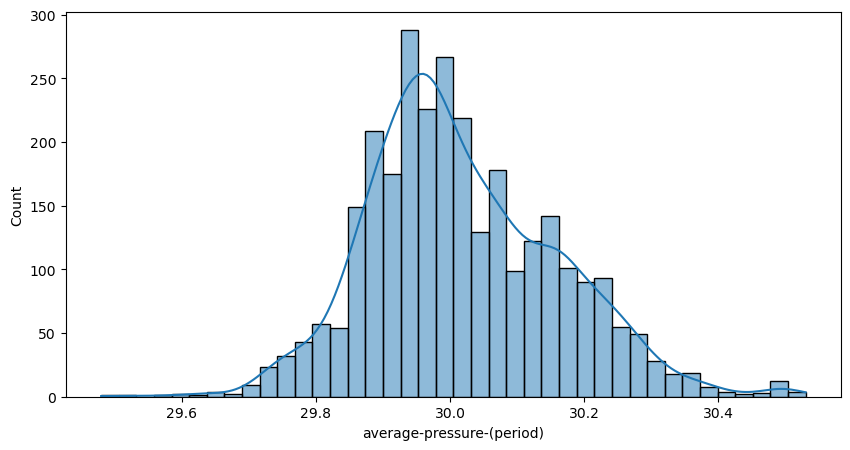

In [29]:
sns.histplot(data=df,x='average-pressure-(period)',kde=True)
plt.show()

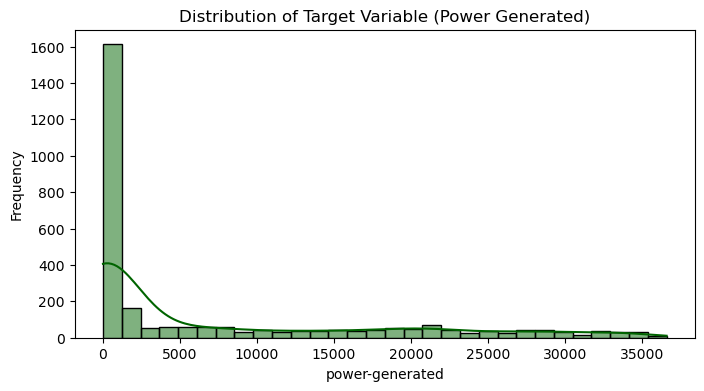


Target Skewness: 1.31
Target is highly skewed consider log transformation during modeling.


In [30]:
# Distribution of Target Variable

plt.figure(figsize=(8, 4))
sns.histplot(df['power-generated'], kde=True, color='darkgreen', bins=30)
plt.title("Distribution of Target Variable (Power Generated)")
plt.xlabel("power-generated")
plt.ylabel("Frequency")
plt.show()

print(f"\nTarget Skewness: {df['power-generated'].skew():.2f}")
if abs(df['power-generated'].skew()) > 1:
    print("Target is highly skewed consider log transformation during modeling.")
else:
    print("Target is approximately symmetric — suitable for regression.")

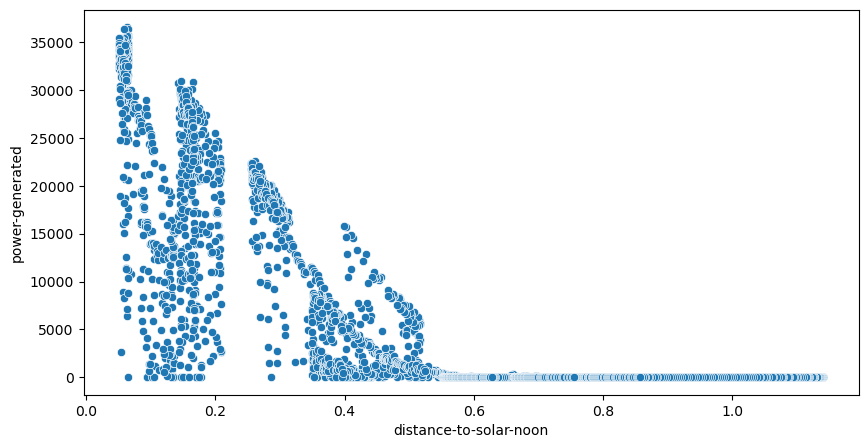

In [31]:
sns.scatterplot(x='distance-to-solar-noon',y='power-generated',data=df)
plt.show()

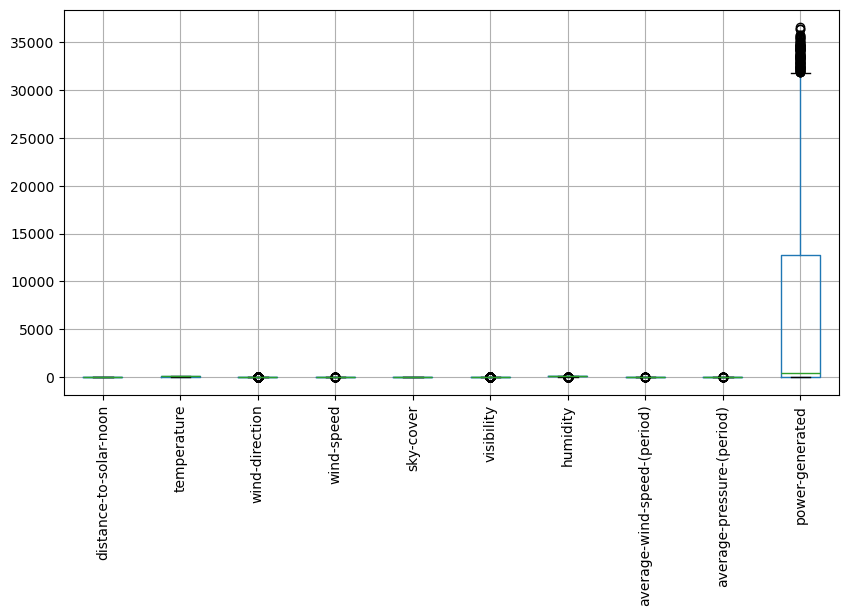

In [32]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [33]:
### outlier capping
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25) #It finds the value at the given percentile in the data. Q1=25%
    Q3=df[column].quantile(0.75) #Q3 = 75%
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)
# Each and every column is selected and done outlier capping

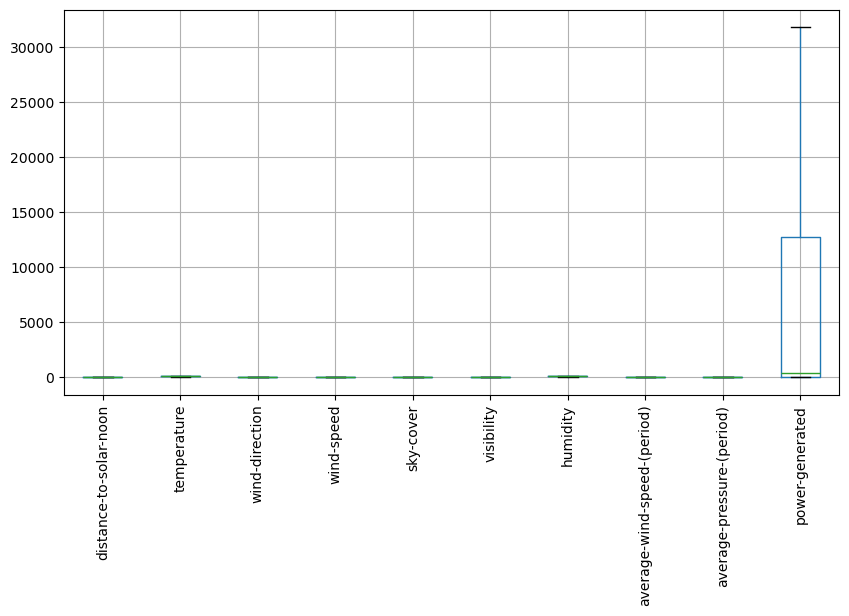

In [34]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [35]:
## All the outliers have been removed

In [36]:
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28.0,7.5,0,10.0,75.0,8.0,29.82,0.0
1,0.628535,69,28.0,7.5,0,10.0,77.0,5.0,29.85,0.0
2,0.397172,69,28.0,7.5,0,10.0,70.0,0.0,29.89,5418.0
3,0.165810,69,28.0,7.5,0,10.0,36.5,0.0,29.91,25477.0
4,0.065553,69,28.0,7.5,0,10.0,36.5,3.0,29.89,30069.0


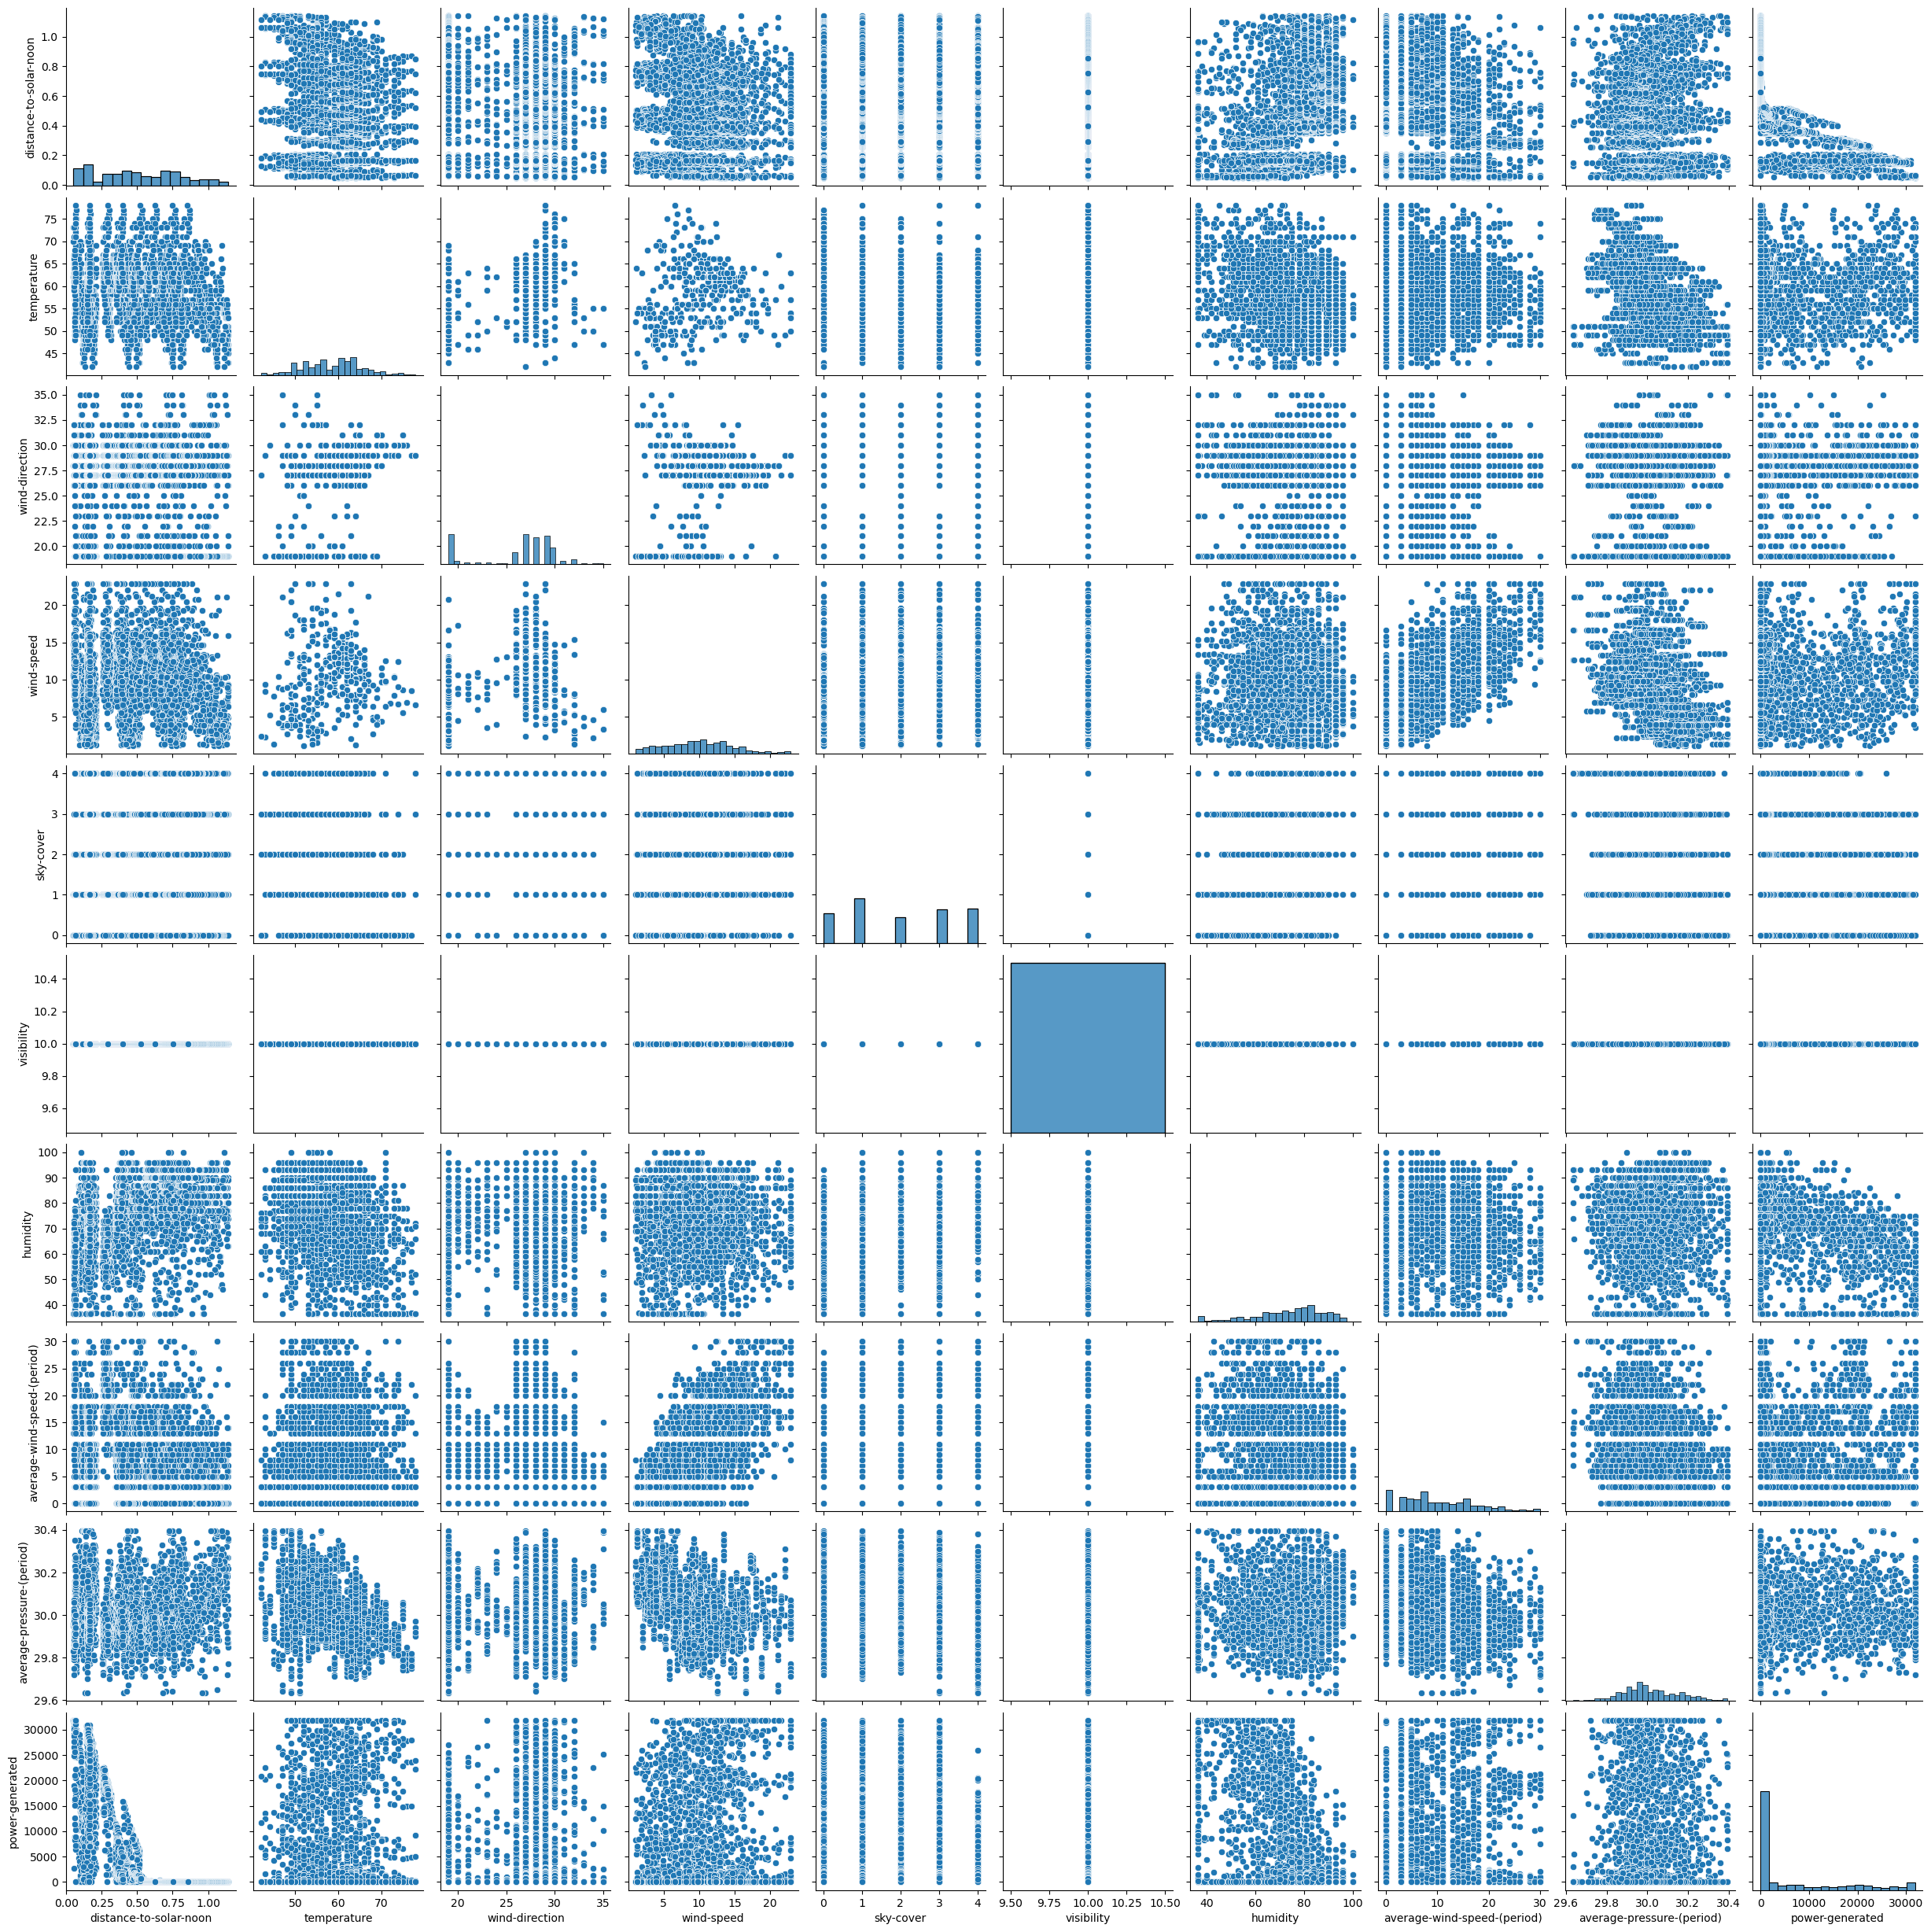

In [37]:
sns.pairplot(df)
plt.show()

In [38]:
#### f_regression
target=df[['power-generated']]
features=df.drop(columns=['power-generated'])

In [39]:
f_reg=f_regression(features,target)

In [40]:
features.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)'],
      dtype='object')

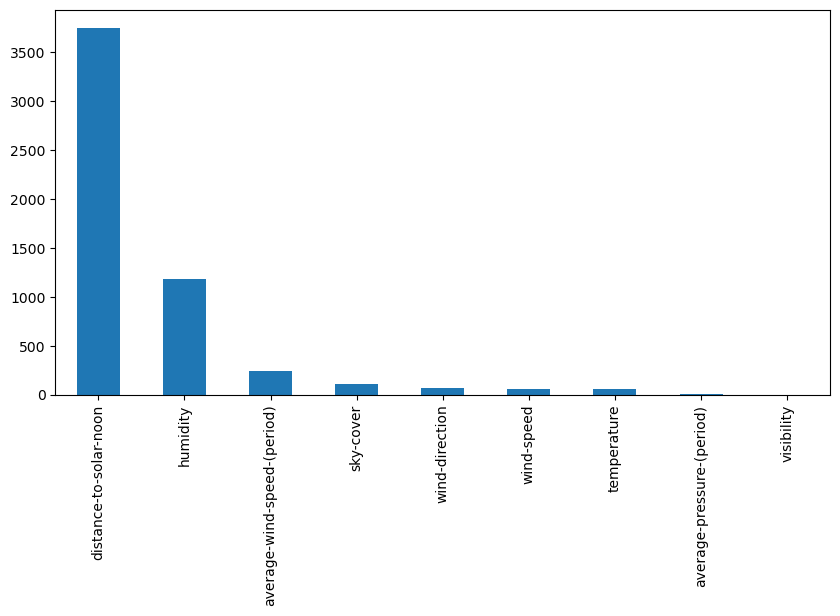

In [41]:
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [42]:
# Here visibility has no relationship between target so we are removing them

In [43]:
## VIF
vif= pd.DataFrame()

In [44]:
vif['features']= features.columns
vif['VIF']= [variance_inflation_factor(features.values,i) for i in range(len(features.columns))]

In [45]:
vif.sort_values(by='VIF',ascending=False)
# Visibility also has high multicollinearity with other features, so we need to remove that feature

,features,VIF
5,visibility,73405.212552
3,wind-speed,2.109412
7,average-wind-speed-(period),2.057511
6,humidity,1.575537
8,average-pressure-(period),1.508927
1,temperature,1.496228
4,sky-cover,1.388262
0,distance-to-solar-noon,1.251183
2,wind-direction,1.232470


In [46]:
features.drop(columns=['visibility'],inplace=True)

In [47]:
features.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,average-wind-speed-(period),average-pressure-(period)
0,0.859897,69,28.0,7.5,0,75.0,8.0,29.82
1,0.628535,69,28.0,7.5,0,77.0,5.0,29.85
2,0.397172,69,28.0,7.5,0,70.0,0.0,29.89
3,0.165810,69,28.0,7.5,0,36.5,0.0,29.91
4,0.065553,69,28.0,7.5,0,36.5,3.0,29.89


In [48]:
target.head()

,power-generated
0,0.0
1,0.0
2,5418.0
3,25477.0
4,30069.0


In [49]:
features.corr()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,average-wind-speed-(period),average-pressure-(period)
distance-to-solar-noon,1.000000,-0.145235,-0.097256,-0.146580,-0.015183,0.377035,-0.214650,0.083487
temperature,-0.145235,1.000000,0.333577,0.101729,-0.230673,-0.212191,0.056532,-0.439066
wind-direction,-0.097256,0.333577,1.000000,0.230455,-0.232934,-0.115121,0.154899,-0.199716
wind-speed,-0.146580,0.101729,0.230455,1.000000,0.109571,-0.002451,0.672000,-0.384099
sky-cover,-0.015183,-0.230673,-0.232934,0.109571,1.000000,0.396197,0.045516,-0.086125
humidity,0.377035,-0.212191,-0.115121,-0.002451,0.396197,1.000000,-0.227000,0.021715
average-wind-speed-(period),-0.214650,0.056532,0.154899,0.672000,0.045516,-0.227000,1.000000,-0.295260
average-pressure-(period),0.083487,-0.439066,-0.199716,-0.384099,-0.086125,0.021715,-0.295260,1.000000


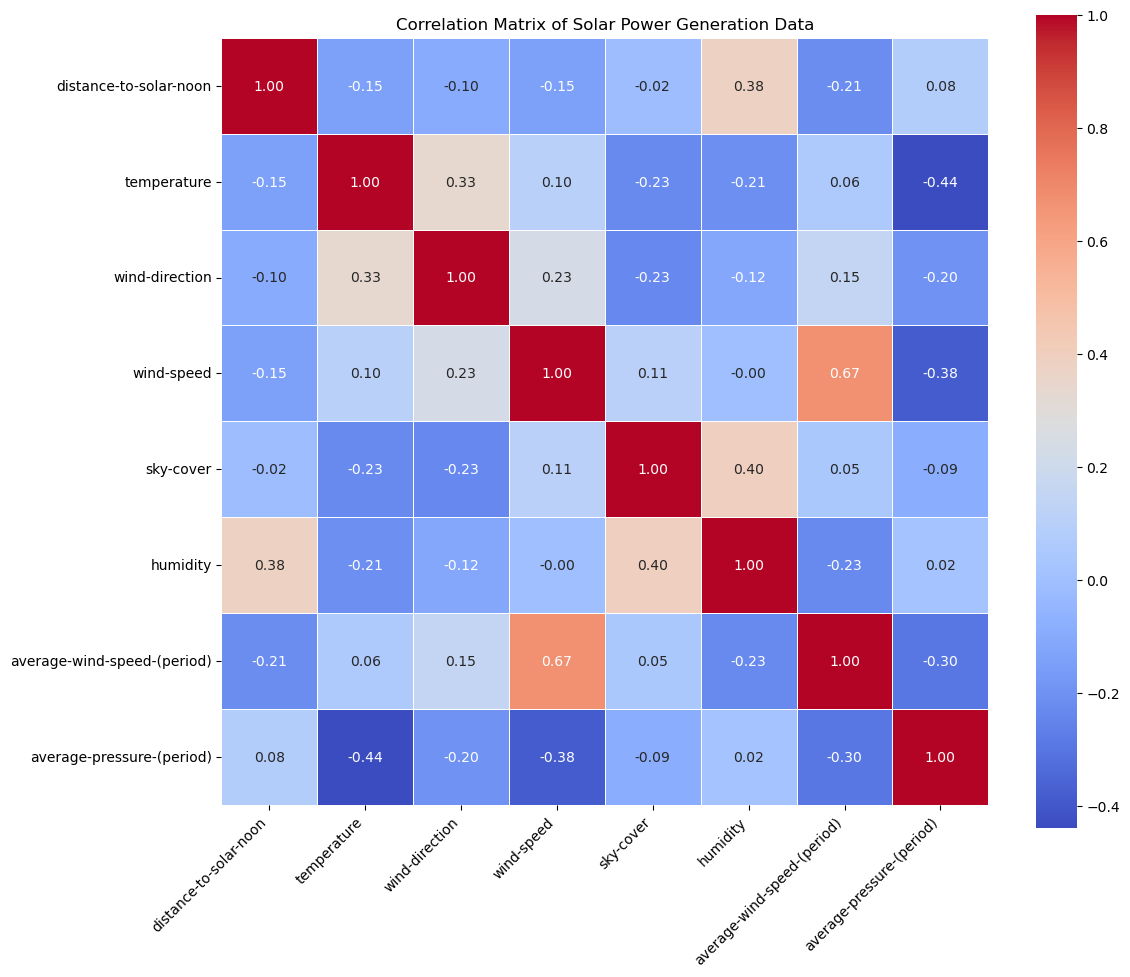

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    features.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=.5,
    annot_kws={"size": 10}
)
plt.title('Correlation Matrix of Solar Power Generation Data')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

This analysis confirms that solar power generation is primarily driven by the time of day (distance to solar noon) and atmospheric conditions (sky cover and humidity).

## **Model Building**

In [51]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
features.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,average-wind-speed-(period),average-pressure-(period)
0,0.859897,69,28.0,7.5,0,75.0,8.0,29.82
1,0.628535,69,28.0,7.5,0,77.0,5.0,29.85
2,0.397172,69,28.0,7.5,0,70.0,0.0,29.89
3,0.165810,69,28.0,7.5,0,36.5,0.0,29.91
4,0.065553,69,28.0,7.5,0,36.5,3.0,29.89


In [53]:
std_sca=StandardScaler()
std_sca_target=StandardScaler()

In [54]:
features_scaled=std_sca.fit_transform(features)

In [55]:
target_scaled=std_sca_target.fit_transform(target)

In [56]:
features = pd.DataFrame(features_scaled, columns=features.columns)
target = pd.DataFrame(target_scaled, columns=target.columns)

In [57]:
features.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,humidity,average-wind-speed-(period),average-pressure-(period)
0,1.196470,1.539362,0.426405,-0.540339,-1.407718,0.088304,-0.292974,-1.414241
1,0.420133,1.539362,0.426405,-0.540339,-1.407718,0.226904,-0.710549,-1.199051
2,-0.356203,1.539362,0.426405,-0.540339,-1.407718,-0.258194,-1.406506,-0.912131
3,-1.132540,1.539362,0.426405,-0.540339,-1.407718,-2.579734,-1.406506,-0.768671
4,-1.468953,1.539362,0.426405,-0.540339,-1.407718,-2.579734,-0.988931,-0.912131


In [58]:
target.head()

,power-generated
0,-0.682189
1,-0.682189
2,-0.147463
3,1.832247
4,2.285451


In [59]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=42)

In [60]:
### Model 1 :- Linear Regression

In [61]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [62]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
results = []
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))

In [63]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

In [64]:
svr = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.1
)
svr.fit(x_train, y_train)
y_pred_svr = svr.predict(x_test)
results.append(evaluate_model("Support Vector Regressor (SVR)", y_test, y_pred_svr))

In [65]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
results.append(evaluate_model("Random Forest Regressor", y_test, y_pred_rf))

In [66]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(x_train, y_train)
y_pred_gbr = gbr.predict(x_test)
results.append(evaluate_model("Gradient Boosting Regressor", y_test, y_pred_gbr))

In [67]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")


,Model,MAE,RMSE,R2
4,Gradient Boosting Regressor,0.153039,0.288534,0.919516
3,Random Forest Regressor,0.144185,0.316776,0.902990
2,Support Vector Regressor (SVR),0.214099,0.360981,0.874025
0,Linear Regression,0.493137,0.617675,0.631165
1,Ridge Regression,0.493126,0.617687,0.631149


In [68]:
ridge = Ridge()

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(x_train, y_train)
best_ridge = ridge_grid.best_estimator_
y_pred_ridge_tuned = best_ridge.predict(x_test)
results.append(
    evaluate_model("Ridge Regression (Tuned)", y_test, y_pred_ridge_tuned)
)
print("Best Ridge alpha:", ridge_grid.best_params_)


Best Ridge alpha: {'alpha': 10}


In [69]:
svr = SVR(kernel='rbf')

svr_params = {
    "C": [1, 10, 100],
    "epsilon": [0.01, 0.1, 0.2],
    "gamma": ['scale', 0.1, 0.01]
}

svr_grid = GridSearchCV(
    svr,
    svr_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

svr_grid.fit(x_train, y_train)

best_svr = svr_grid.best_estimator_

y_pred_svr_tuned = best_svr.predict(x_test)

results.append(
    evaluate_model("SVR (Tuned)", y_test, y_pred_svr_tuned)
)

print("Best SVR params:", svr_grid.best_params_)


Best SVR params: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}


In [70]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(x_test)

results.append(
    evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf_tuned)
)

print("Best RF params:", rf_grid.best_params_)


Best RF params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [71]:
gbr = GradientBoostingRegressor(random_state=42)

gbr_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5]
}
gbr_grid = GridSearchCV(
    gbr,
    gbr_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gbr_grid.fit(x_train, y_train)
best_gbr = gbr_grid.best_estimator_

y_pred_gbr_tuned = best_gbr.predict(x_test)

results.append(
    evaluate_model("Gradient Boosting (Tuned)", y_test, y_pred_gbr_tuned)
)

print("Best Gradient Boosting params:", gbr_grid.best_params_)

Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}


In [72]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
8,Gradient Boosting (Tuned),0.142037,0.287686,0.919989
4,Gradient Boosting Regressor,0.153039,0.288534,0.919516
7,Random Forest (Tuned),0.142945,0.316487,0.903167
3,Random Forest Regressor,0.144185,0.316776,0.902990
2,Support Vector Regressor (SVR),0.214099,0.360981,0.874025
6,SVR (Tuned),0.203145,0.362145,0.873212
0,Linear Regression,0.493137,0.617675,0.631165
1,Ridge Regression,0.493126,0.617687,0.631149
5,Ridge Regression (Tuned),0.493023,0.617809,0.631004


In [73]:
# So we are choosing Gradient Boosting which has been tuned because of low rmse score

In [74]:
y_pred_best = best_gbr.predict(x_test)
residuals = y_test.squeeze() - y_pred_best

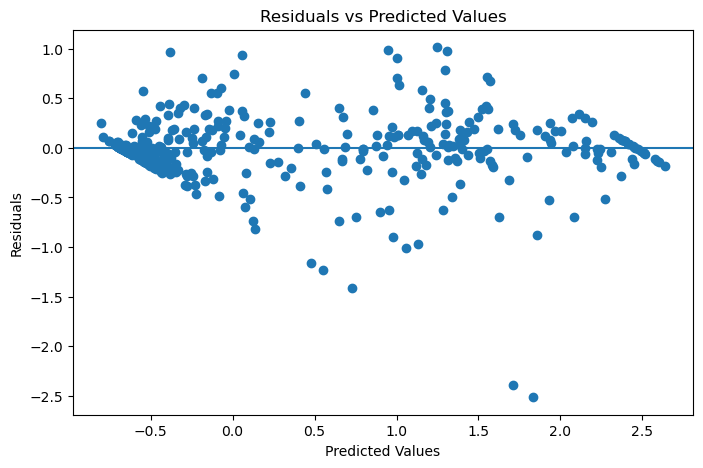

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

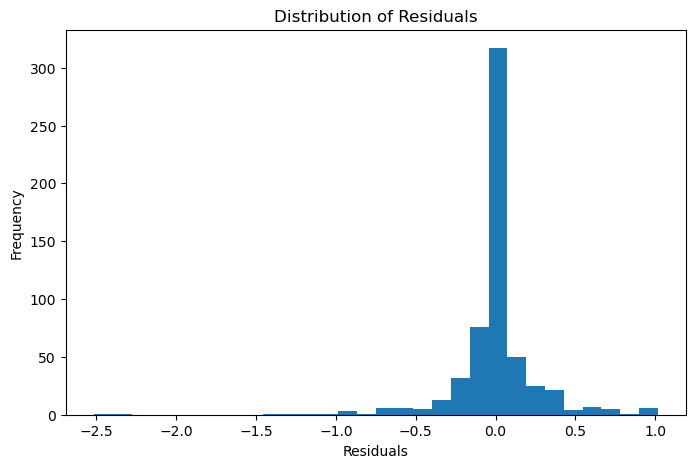

In [76]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

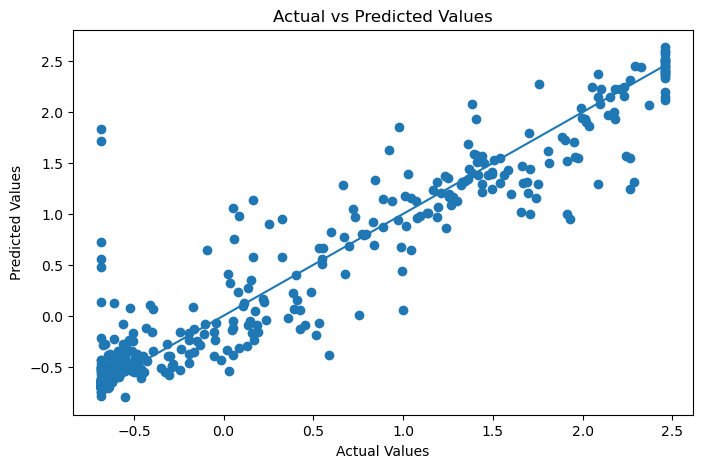

In [77]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [78]:
# Points close to diagonal line

In [79]:
import pandas as pd

gbr_importance = pd.Series(
    best_gbr.feature_importances_,
    index=features.columns
).sort_values(ascending=False)

gbr_importance

distance-to-solar-noon         0.815329
sky-cover                      0.077759
humidity                       0.047730
wind-speed                     0.017377
wind-direction                 0.015907
average-pressure-(period)      0.009928
temperature                    0.008810
average-wind-speed-(period)    0.007162
dtype: float64

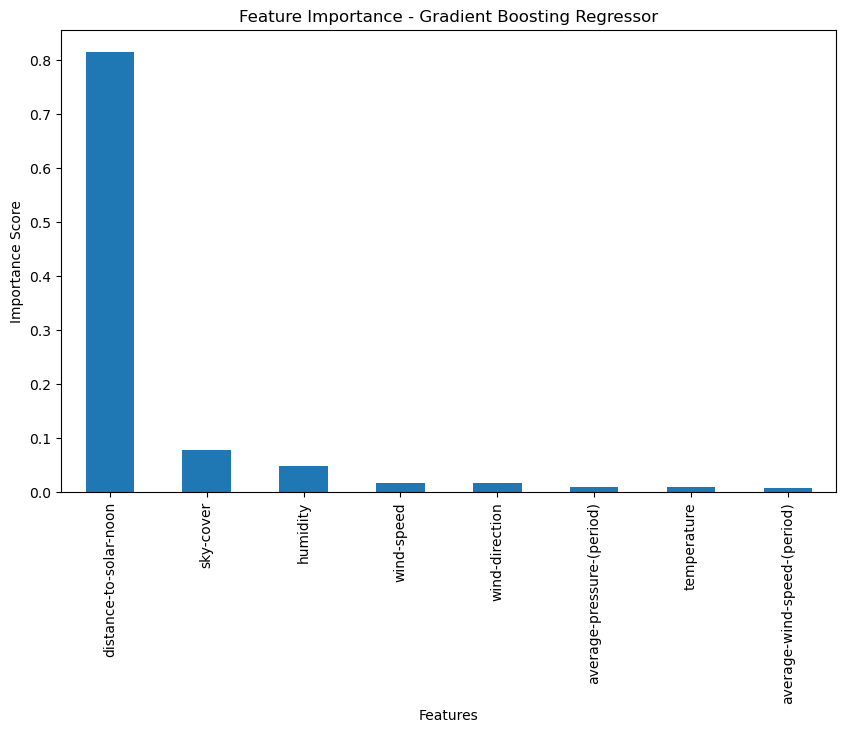

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
gbr_importance.plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Gradient Boosting Regressor")
plt.show()

In [81]:
gbr_importance.head(5)

distance-to-solar-noon    0.815329
sky-cover                 0.077759
humidity                  0.047730
wind-speed                0.017377
wind-direction            0.015907
dtype: float64

In [82]:
import pickle

# Save the model
pickle.dump(best_gbr, open("gbr_model.pkl", "wb"))

# Save the feature scaler (the one used for x_train)
pickle.dump(std_sca, open("scaler_features.pkl", "wb"))

pickle.dump(std_sca_target, open("scaler_target.pkl", "wb"))